In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('Data/Dataset_clean_n111.csv')

In [24]:
print(df)

     ID_nr  CompComf  Comp 1  Comp 2  Comp 3  Comp 4  Comp 5  Comp 6  Comp 7  \
0      101         8       1       1       1       3       2       2       1   
1      102        10       1       1       1       1       2       1       1   
2      103         8       1       2       2       1       5       2       2   
3      104         8       1       2       1       3       1       2       2   
4      105         5       2       4       1       1       4       2       2   
..     ...       ...     ...     ...     ...     ...     ...     ...     ...   
105    207         7       2       3       1       2       1       2       2   
106    208         3       4       5       4       5       4       5       5   
107    209        10       1       5       1       2       1       2       1   
108    210         7       3       3       2       3       4       3       3   
109    211         8       1       2       1       1       1       1       2   

     Comp 8  ...  Comp 30  Comp 31     

In [4]:
df[pd.to_numeric(df['Age'], errors='coerce').notnull()]

,ID_nr,CompComf,Comp 1,Comp 2,Comp 3,Comp 4,Comp 5,Comp 6,Comp 7,Comp 8,...,Comp 30,Comp 31,Sex,Age,IsProgL,IsNotOS,IsNotBrowser,IsRAM,IsPDF,Kohort
0,101,8,1,1,1,3,2,2,5,1,...,1,3,Man,38.0,1,1,1,1,1,1
1,102,10,1,1,1,1,2,1,5,1,...,2,1,Man,32.0,1,1,1,1,1,1
2,103,8,1,2,2,1,5,2,4,2,...,3,2,Kvinna,23.0,0,1,1,0,0,1
3,104,8,1,2,1,3,1,2,4,1,...,2,2,Kvinna,22.0,1,1,1,0,1,1
4,105,5,2,4,1,1,4,2,4,4,...,2,4,Kvinna,20.0,1,1,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,207,7,2,3,1,2,1,2,4,2,...,4,2,Kvinna,20.0,1,1,1,0,1,3
106,208,3,4,5,4,5,4,5,1,4,...,2,4,Kvinna,21.0,1,1,1,0,1,3
107,209,10,1,5,1,2,1,2,5,2,...,2,3,Kvinna,35.0,0,1,1,0,1,3
108,210,7,3,3,2,3,4,3,3,4,...,2,2,Kvinna,19.0,1,0,1,0,1,3


In [23]:
for col in ["Comp 7", "Comp 10", "Comp 14", "Comp 21", "Comp 22", "Comp 28", "Comp 29"]:
    df[col]=6-df[col]
X_mask = df.columns.str.contains("Comp .*")
X = df.loc[:,X_mask]
y_mask = df.columns.str.contains("CompComf")
y = df.loc[:, y_mask]

In [ ]:
import matplotlib

from sklearn.inspection import permutation_importance
from sklearn.utils.fixes import parse_version


def plot_permutation_importance(clf, X, y, ax):
    result = permutation_importance(clf, X, y, n_repeats=10, random_state=42, n_jobs=2)
    perm_sorted_idx = result.importances_mean.argsort()

    # `labels` argument in boxplot is deprecated in matplotlib 3.9 and has been
    # renamed to `tick_labels`. The following code handles this, but as a
    # scikit-learn user you probably can write simpler code by using `labels=...`
    # (matplotlib < 3.9) or `tick_labels=...` (matplotlib >= 3.9).
    tick_labels_parameter_name = (
        "tick_labels"
        if parse_version(matplotlib.__version__) >= parse_version("3.9")
        else "labels"
    )
    tick_labels_dict = {tick_labels_parameter_name: X.columns[perm_sorted_idx]}
    ax.boxplot(result.importances[perm_sorted_idx].T, vert=False, **tick_labels_dict)
    ax.axvline(x=0, color="k", linestyle="--")
    return ax

In [25]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

#X, y = load_breast_cancer(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
print(f"Baseline accuracy on test data: {clf.score(X_test, y_test):.2}")

/home/bearnix/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Baseline accuracy on test data: 0.29


In [15]:
print(X)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean concavity  mean concave points  mea

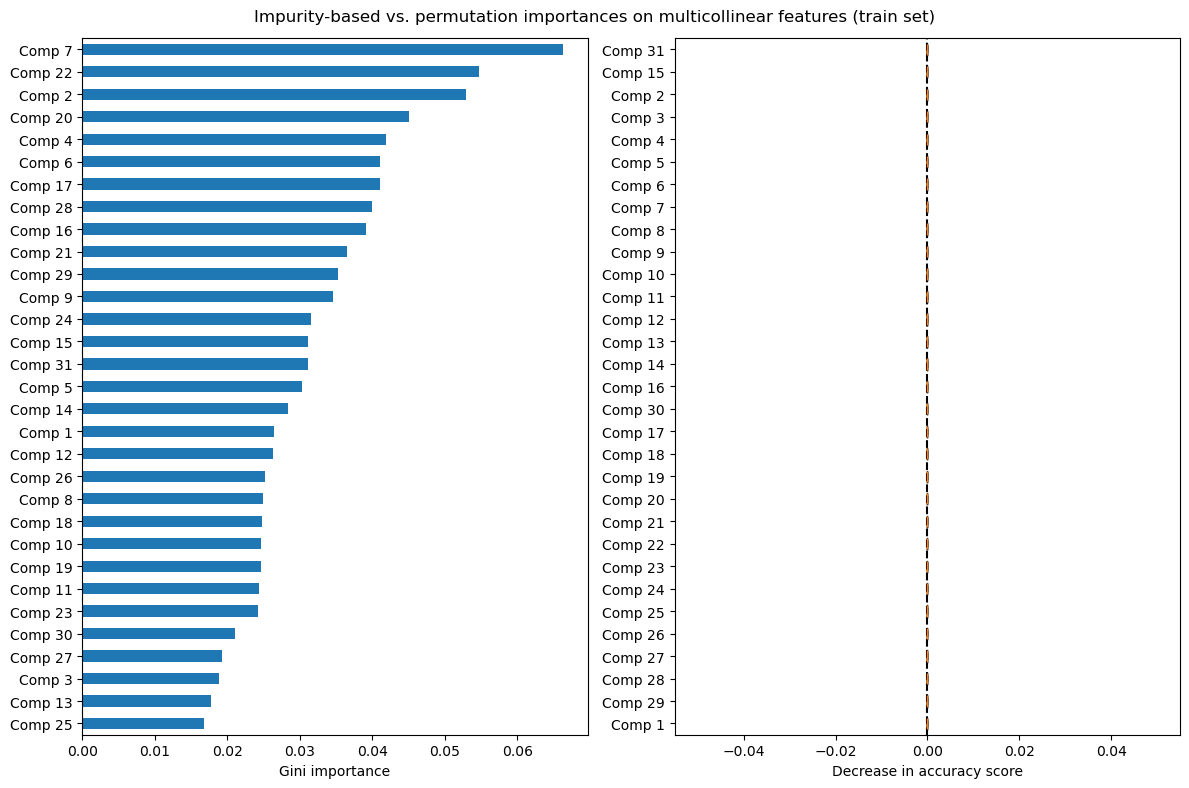

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mdi_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
tree_importance_sorted_idx = np.argsort(clf.feature_importances_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
mdi_importances.sort_values().plot.barh(ax=ax1)
ax1.set_xlabel("Gini importance")
plot_permutation_importance(clf, X_train, y_train, ax2)
ax2.set_xlabel("Decrease in accuracy score")
fig.suptitle(
    "Impurity-based vs. permutation importances on multicollinear features (train set)"
)
_ = fig.tight_layout()

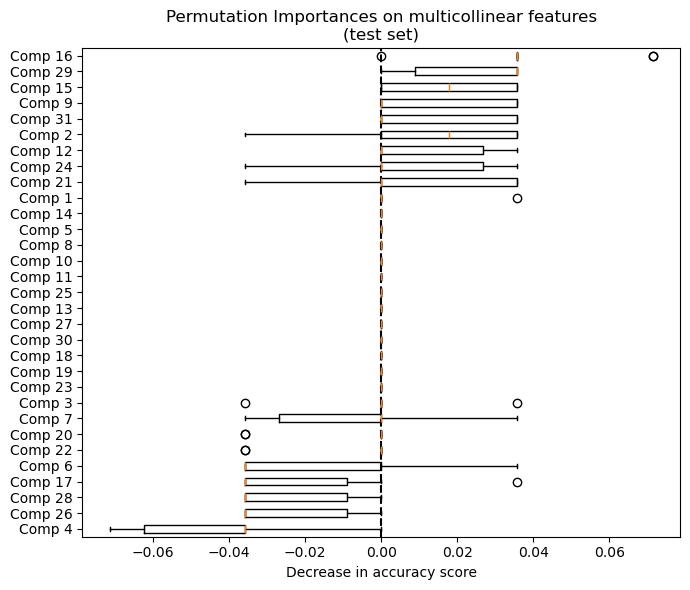

In [27]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_permutation_importance(clf, X_test, y_test, ax)
ax.set_title("Permutation Importances on multicollinear features\n(test set)")
ax.set_xlabel("Decrease in accuracy score")
_ = ax.figure.tight_layout()

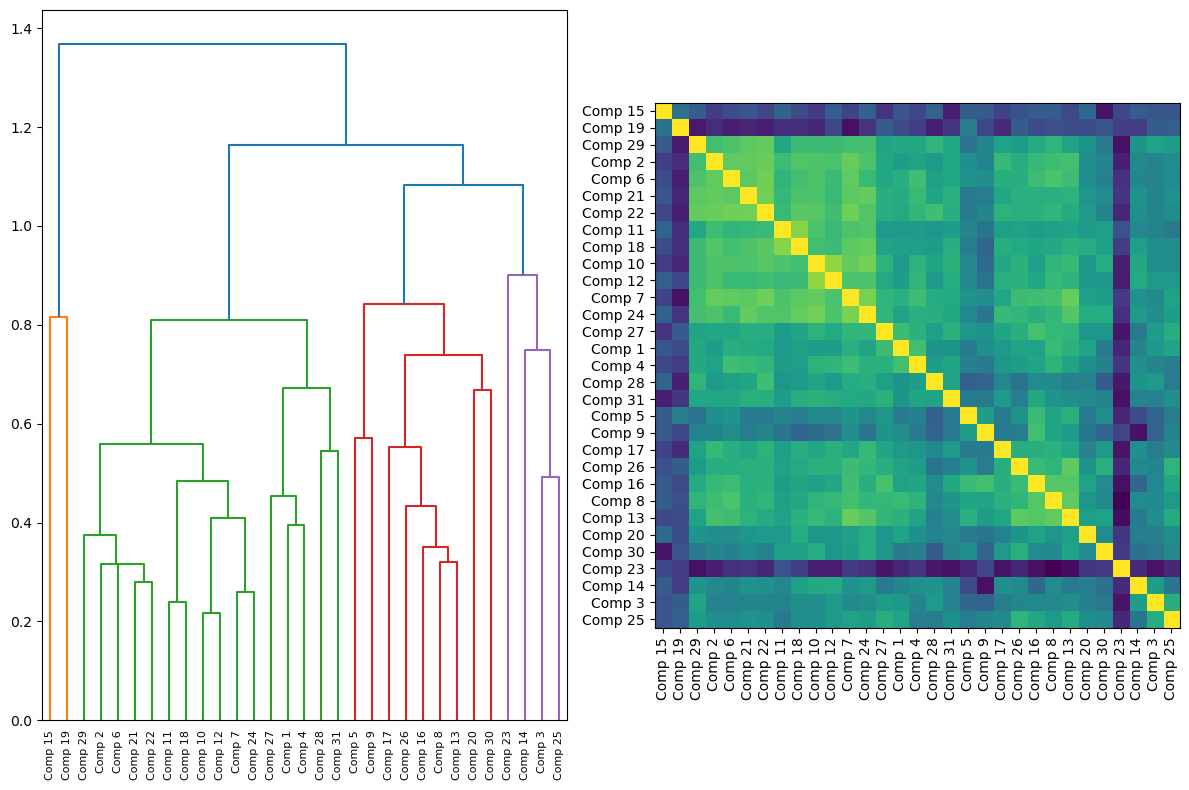

In [69]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr
from scipy.stats import pearsonr


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
corr = spearmanr(X).correlation
corr2 = np.asarray(X.corr())
corr2 = (corr2 + corr2.T) / 2
# Ensure the correlation matrix is symmetric
corr = (corr + corr.T) / 2
np.fill_diagonal(corr, 1)
np.fill_diagonal(corr2, 1)

# We convert the correlation matrix to a distance matrix before performing
# hierarchical clustering using Ward's linkage.
distance_matrix = 1 - np.abs(corr)
dist_linkage = hierarchy.ward(squareform(distance_matrix))
dendro = hierarchy.dendrogram(
    dist_linkage, labels=X.columns.to_list(), ax=ax1, leaf_rotation=90
)
dendro_idx = np.arange(0, len(dendro["ivl"]))

ax2.imshow(corr[dendro["leaves"], :][:, dendro["leaves"]])
ax2.set_xticks(dendro_idx)
ax2.set_yticks(dendro_idx)
ax2.set_xticklabels(dendro["ivl"], rotation="vertical")
ax2.set_yticklabels(dendro["ivl"])
_ = fig.tight_layout()

In [75]:
#print(1-abs(corr))
hierarchy.fcluster(dist_linkage, t=0.5, criterion='distance')

array([ 5,  3, 14,  5,  8,  3,  4, 10,  9,  4,  4,  4, 10, 15,  1, 10, 11,
        4,  2, 12,  3,  3, 16,  4, 14, 10,  5,  6,  3, 13,  7],
      dtype=int32)

In [ ]:
from collections import defaultdict

cluster_ids = hierarchy.fcluster(dist_linkage, 1, criterion="distance")
cluster_id_to_feature_ids = defaultdict(list)
for idx, cluster_id in enumerate(cluster_ids):
    cluster_id_to_feature_ids[cluster_id].append(idx)
selected_features = [v[0] for v in cluster_id_to_feature_ids.values()]
selected_features_names = X.columns[selected_features]
print(selected_features_names)
X_train_sel = X_train[selected_features_names]
X_test_sel = X_test[selected_features_names]

clf_sel = RandomForestClassifier(n_estimators=100, random_state=42)
clf_sel.fit(X_train_sel, y_train)
print(
    "Baseline accuracy on test data with features removed:"
    f" {clf_sel.score(X_test_sel, y_test):.2}"
)

Index(['Comp 1', 'Comp 3', 'Comp 5', 'Comp 15'], dtype='object')


/home/bearnix/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Baseline accuracy on test data with features removed: 0.18


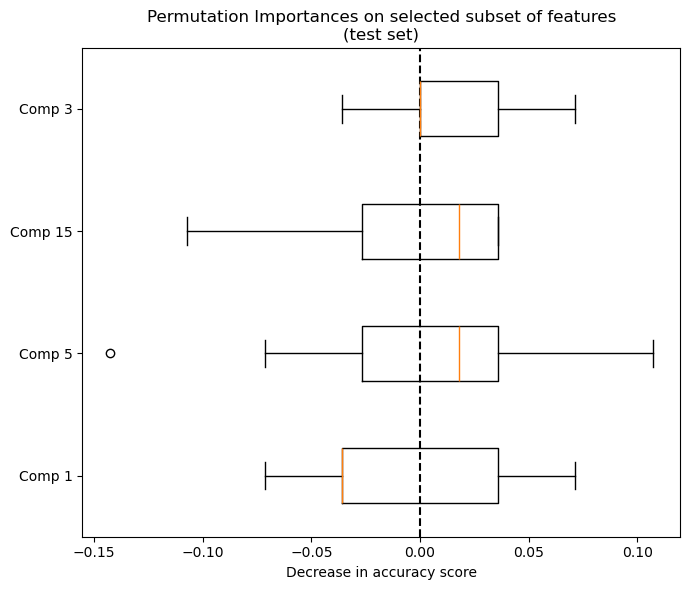

In [34]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_permutation_importance(clf_sel, X_test_sel, y_test, ax)
ax.set_title("Permutation Importances on selected subset of features\n(test set)")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()
plt.show()

In [48]:
from sklearn.feature_selection import RFE
from sklearn.svm import SVR
#X, y = make_friedman1(n_samples=50, n_features=10, random_state=0)
estimator = SVR(kernel="linear")
selector = RFE(estimator, n_features_to_select=15, step=1)
selector = selector.fit(X, np.asarray(y).ravel())
selector.support_
print(X)

     Comp 1  Comp 2  Comp 3  Comp 4  Comp 5  Comp 6  Comp 7  Comp 8  Comp 9  \
0         1       1       1       3       2       2       1       1       5   
1         1       1       1       1       2       1       1       1       1   
2         1       2       2       1       5       2       2       2       3   
3         1       2       1       3       1       2       2       1       3   
4         2       4       1       1       4       2       2       4       4   
..      ...     ...     ...     ...     ...     ...     ...     ...     ...   
105       2       3       1       2       1       2       2       2       4   
106       4       5       4       5       4       5       5       4       5   
107       1       5       1       2       1       2       1       2       1   
108       3       3       2       3       4       3       3       4       4   
109       1       2       1       1       1       1       2       1       3   

     Comp 10  ...  Comp 22  Comp 23  Comp 24  Comp 

In [ ]:
from collections import Counter

In [62]:
class Item:
    def __init__(self, series):
        self.name = series.name
        self.freq = Counter(series)
        self.prob = self.freq
        tot = sum(self.prob.values())
        for key in self.prob.keys():
            self.prob[key] = self.prob[key]/tot
            
    def entropy(self):
        _entropy = 0.0
        for prob in self.prob.values():
            _entropy -= prob*np.log(prob)
        return _entropy

In [48]:
i = Item(df['Comp 1'])

110


In [49]:
i.name

'Comp 1'

In [50]:
i.prob

Counter({1: 0.43636363636363634,
         2: 0.35454545454545455,
         3: 0.11818181818181818,
         4: 0.08181818181818182,
         5: 0.00909090909090909})

In [69]:
i.entropy()
#list(df)
#spike_cols = [col for col in df.columns if 'Comp ' in col]
#print(spike_cols)

1.2294265879227715

In [64]:
class Survey:
    def __init__(self, df):
        self.items = []
        for item in ( col for col in df.columns if 'Comp ' in col) :
            self.items.append(Item(df[item]))

    def entropy(self):
        _entropy = 0.0
        for item in self.items:
            _entropy += item.entropy()
        return _entropy
        

In [66]:
survey = Survey(df)

In [67]:
survey.entropy()

44.8164534996561

In [68]:
survey.entropy()/len(survey.items)

1.4456920483760032

In [71]:
for item in survey.items:
    print(item.entropy())

1.2294265879227715
1.5772440061259558
1.1276494986719499
1.4944201288113055
1.5453132292020695
1.4990542038831243
1.459794357172361
1.5395080024661405
1.5058841325675445
1.4850987372183704
1.558801263463559
1.4935696596881496
1.3679170869850268
1.4722485094295894
1.4305962168819084
1.562987937364845
1.4437087017365842
1.5577499257629137
1.281589689507146
1.5811728066889925
1.3291592687404623
1.5146327727777416
1.5662131310856213
1.4878389688805538
0.9499181861818932
1.4335511340011513
1.46649678048324
1.4229319626525547
1.4752966628154405
1.4804446393594786
1.4762353111276636
